# Axis 2A: End-to-End LLM-Based PICO Information Extraction
## EBM-NLP Dataset | Qwen2.5-1.5B-Instruct Model
### Notebook: 04_axis2A_qwen_full_abstracts

This notebook implements and evaluates end-to-end LLM extraction
of PICO fields (Participants, Interventions, Outcomes) from
clinical trial abstracts using:
- **Zero-shot prompting** — no examples given
- **Few-shot prompting** — 3 worked examples given

**Model:** Qwen/Qwen2.5-1.5B-Instruct  
**Dataset:** EBM-NLP (100 test abstracts)  
**Input:** Full abstracts (not single sentences)

**Required file to upload:** `sentences_df.csv`  
(generated by notebook 01_data_exploration)

In [2]:
# HYPOTHESIS — Written BEFORE experiments


print("""
RESEARCH QUESTION:
Does providing examples (few-shot) improve PICO extraction
compared to no examples (zero-shot) for an instruction-tuned LLM?

HYPOTHESIS:
We hypothesise that few-shot prompting will outperform zero-shot
prompting for PICO extraction because:

1. PICO categories have specific medical definitions that even
   an instruction-tuned model may misinterpret without examples.
   Showing 3 worked examples clarifies exactly what counts as
   Participants vs Interventions vs Outcomes.

2. Few-shot examples demonstrate the expected OUTPUT FORMAT,
   reducing parsing errors from malformed model responses.

3. Zero-shot will struggle most with Participants because patient
   descriptions vary widely and lack distinctive numerical markers.

4. Both approaches will perform better on Outcomes because medical
   results contain distinctive numerical markers (%, p-values).

CONTEXT — Previous experiment with Flan-T5-Large:
In our earlier experiment on single sentences, few-shot HURT
performance (57.3% vs 26.7%). We attributed this to:
  - Flan-T5 being too small to benefit from examples
  - Single sentences lacking cross-sentence context

This experiment addresses both issues:
  - Qwen2.5-1.5B — proper instruction-tuned model
  - Full abstracts — providing complete context

Expected ranking: Few-shot > Zero-shot
Expected best field: Outcomes (numerical markers)
Expected worst field: Participants (most variable language)
""")

print(" Hypothesis documented!")


RESEARCH QUESTION:
Does providing examples (few-shot) improve PICO extraction
compared to no examples (zero-shot) for an instruction-tuned LLM?

HYPOTHESIS:
We hypothesise that few-shot prompting will outperform zero-shot
prompting for PICO extraction because:

1. PICO categories have specific medical definitions that even
   an instruction-tuned model may misinterpret without examples.
   Showing 3 worked examples clarifies exactly what counts as
   Participants vs Interventions vs Outcomes.

2. Few-shot examples demonstrate the expected OUTPUT FORMAT,
   reducing parsing errors from malformed model responses.

3. Zero-shot will struggle most with Participants because patient
   descriptions vary widely and lack distinctive numerical markers.

4. Both approaches will perform better on Outcomes because medical
   results contain distinctive numerical markers (%, p-values).

CONTEXT — Previous experiment with Flan-T5-Large:
In our earlier experiment on single sentences, few-shot HURT
p

In [3]:
!pip install -q transformers accelerate sentencepiece

## Step 1: Data Loading
We load sentences_df.csv (generated by notebook 01_data_exploration)
and group sentence-level data into full abstracts for extraction.

IMPORTANT: Upload sentences_df.csv before running this cell.

In [4]:
# STEP 1 — LOAD AND PREPARE DATA

#  Upload sentences_df.csv first using the
#  file panel on the left sidebar in Colab

import pandas as pd
import os

# Check file exists
if not os.path.exists("sentences_df.csv"):
    raise FileNotFoundError(
        "sentences_df.csv not found!\n"
        "Please upload it from: Desktop/ebm_nlp_project/outputs/sentences_df.csv\n"
        "Use the folder icon on the left sidebar in Colab."
    )

# Load sentences
df = pd.read_csv("sentences_df.csv")
print(f"   Loaded sentences_df.csv: {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"   Label distribution:\n{df['label'].value_counts()}")

   Loaded sentences_df.csv: (5590, 6)
   Columns: ['doc_id', 'sentence', 'label', 'participants_count', 'interventions_count', 'outcomes_count']
   Label distribution:
label
outcomes         2195
interventions    1406
none             1220
participants      769
Name: count, dtype: int64


In [5]:
# STEP 2 — GROUP SENTENCES INTO FULL ABSTRACTS


grouped = df.groupby("doc_id")
abstract_rows = []

for doc_id, group in grouped:
    group = group.reset_index(drop=True)
    abstract_text = " ".join(group["sentence"].astype(str).tolist())

    participants_text = " ".join(
        group[group["label"] == "participants"]["sentence"].astype(str).tolist()
    )
    interventions_text = " ".join(
        group[group["label"] == "interventions"]["sentence"].astype(str).tolist()
    )
    outcomes_text = " ".join(
        group[group["label"] == "outcomes"]["sentence"].astype(str).tolist()
    )

    abstract_rows.append({
        "doc_id": doc_id,
        "abstract_text": abstract_text,
        "gold_participants": participants_text,
        "gold_interventions": interventions_text,
        "gold_outcomes": outcomes_text
    })

abstract_df = pd.DataFrame(abstract_rows)
print(f"  Built abstract_df: {abstract_df.shape}")
print(f"   {len(abstract_df)} full abstracts ready")

  Built abstract_df: (500, 5)
   500 full abstracts ready


In [36]:
# STEP 3 — CREATE TEST SET (100 abstracts)

import numpy as np

# Filter abstracts that have ALL three PICO fields
complete_abstracts = abstract_df[
    (abstract_df["gold_participants"].str.strip() != "") &
    (abstract_df["gold_interventions"].str.strip() != "") &
    (abstract_df["gold_outcomes"].str.strip() != "")
].copy()

# Sample 100 abstracts for evaluation
test_df = complete_abstracts.sample(
    n=min(100, len(complete_abstracts)),
    random_state=42
).reset_index(drop=True)

print(f" Test set created: {len(test_df)} abstracts")
print(f"   All abstracts have complete PICO annotations")
print(f"\nSample abstract:")
print(test_df.loc[0, 'abstract_text'][:300] + "...")

 Test set created: 100 abstracts
   All abstracts have complete PICO annotations

Sample abstract:
Photodynamic therapy with 5-aminolaevulinic acid or placebo for recalcitrant foot and hand warts : randomised double-blind trial . BACKGROUND Photodynamic therapy ( PDT ) with topical 5-aminolaevulinic acid ( ALA ) followed by irradiation with incoherent light ( ALA-PDT ) for recalcitrant warts have...


## Step 4: Model Setup — Qwen2.5-1.5B-Instruct

We use Qwen2.5-1.5B-Instruct, a proper instruction-following model.
This is an improvement over Flan-T5-Large used in our first experiment
because it is specifically trained to follow natural language instructions.

In [7]:
import torch
from transformers import pipeline

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

pipe = pipeline(
    "text-generation",
    model=model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Pipeline loaded successfully:", model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Pipeline loaded successfully: Qwen/Qwen2.5-1.5B-Instruct


## Zero-Shot Extraction

In the zero-shot setting, the model is given only the task description and the abstract.

No examples are provided. The model relies entirely on its pre-trained knowledge to extract:
- Participants
- Interventions
- Outcomes

This serves as the baseline approach.

In [8]:
def create_zero_shot_prompt(abstract):
    return f"""Extract structured information from the clinical trial abstract below.

Return exactly three lines in this format:
Participants: ...
Interventions: ...
Outcomes: ...

Rules:
- Participants = the people or patient group studied
- Interventions = treatments, drugs, procedures, or study arms
- Outcomes = measured results, endpoints, findings, or effects
- Use only information stated in the abstract
- Do not add explanations
- If a field is missing, write NONE

Abstract:
{abstract}
"""

In [9]:
def run_chat_llm(prompt, max_new_tokens=200):
    output = pipe(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=None,
        return_full_text=False
    )
    return output[0]["generated_text"].strip()

In [10]:
for i in range(3):
    print("=" * 80)
    print(f"ABSTRACT {i} | doc_id = {test_df.loc[i, 'doc_id']}")
    print("=" * 80)

    sample_abstract = test_df.loc[i, "abstract_text"]
    prompt = create_zero_shot_prompt(sample_abstract)
    output = run_chat_llm(prompt)

    print("\nMODEL OUTPUT:\n")
    print(output)
    print("\nGOLD PARTICIPANTS:\n", str(test_df.loc[i, "gold_participants"])[:300])
    print("\nGOLD INTERVENTIONS:\n", str(test_df.loc[i, "gold_interventions"])[:300])
    print("\nGOLD OUTCOMES:\n", str(test_df.loc[i, "gold_outcomes"])[:300])
    print("\n\n")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ABSTRACT 0 | doc_id = 10768434


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MODEL OUTPUT:

### Participants: 
Foot and hand warts

### Interventions: 
ALA-PDT (with 5-aminolaevulinic acid) vs Placebo-PDT

### Outcomes: 
Median relative reduction in wart area; Number of vanishing warts; Difference in relative wart area of persisting warts; Median pain intensity after treatment

GOLD PARTICIPANTS:
 Photodynamic therapy with 5-aminolaevulinic acid or placebo for recalcitrant foot and hand warts : randomised double-blind trial . METHODS Recalcitrant foot and hand warts were randomly assigned to six repetitive ALA-PDT or placebo-PDT interventions combined with standard treatment encompassing pari

GOLD INTERVENTIONS:
 BACKGROUND Photodynamic therapy ( PDT ) with topical 5-aminolaevulinic acid ( ALA ) followed by irradiation with incoherent light ( ALA-PDT ) for recalcitrant warts have had beneficial results . FINDINGS A total of 232 foot and hand warts in 45 patients were entered into the trial : 117 warts were a

GOLD OUTCOMES:
 The area of each wart compared wit

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MODEL OUTPUT:

Participants: Emergency patients with untreated irreversible pulpitis
Interventions: Oral doses of penicillin or placebo
Outcomes: Pain, percussion pain, number of analgesic medications taken

GOLD PARTICIPANTS:
 STUDY DESIGN Forty emergency patients participated , and each had a clinical diagnosis of an irreversible pulpitis .

GOLD INTERVENTIONS:
 Effect of systemic penicillin on pain in untreated irreversible pulpitis . OBJECTIVE The purpose of this prospective , randomized , double-blind study was to determine the effect of penicillin on pain in untreated teeth diagnosed with irreversible pulpitis . Patients randomly received a 7-day oral d

GOLD OUTCOMES:
 Each patient also received ibuprofen ; acetaminophen with codeine ( 30 mg ) ; and a 7-day diary to record pain , percussion pain , and number and type of pain medication taken . RESULTS The administration of penicillin did not significantly ( P > .05 ) reduce pain , percussion pain , or the number o



ABSTRACT 2

## Parsing Model Outputs

The LLM generates free-form text outputs, which must be converted into structured fields.

We implement a parsing function to extract:
- Participants
- Interventions
- Outcomes

This step ensures consistency across predictions and enables quantitative evaluation.

In [11]:
def parse_output(text):
    text = text.replace("###", "").strip()
    lines = text.split("\n")

    participants = []
    interventions = []
    outcomes = []

    current_field = None

    for line in lines:
        line = line.strip()

        if line.lower().startswith("participants:"):
            current_field = "participants"
            content = line.split(":", 1)[1].strip()
            if content:
                participants.append(content)

        elif line.lower().startswith("interventions:"):
            current_field = "interventions"
            content = line.split(":", 1)[1].strip()
            if content:
                interventions.append(content)

        elif line.lower().startswith("outcomes:"):
            current_field = "outcomes"
            content = line.split(":", 1)[1].strip()
            if content:
                outcomes.append(content)

        else:
            # continuation line
            if current_field == "participants":
                participants.append(line)
            elif current_field == "interventions":
                interventions.append(line)
            elif current_field == "outcomes":
                outcomes.append(line)

    return (
        " ".join(participants).strip(),
        " ".join(interventions).strip(),
        " ".join(outcomes).strip()
    )

In [12]:
for i in range(3):
    sample_abstract = test_df.loc[i, "abstract_text"]
    prompt = create_zero_shot_prompt(sample_abstract)
    output = run_chat_llm(prompt)

    p, i_, o = parse_output(output)

    print("=" * 60)
    print(f"DOC {i}")
    print("Parsed Participants:", p)
    print("Parsed Interventions:", i_)
    print("Parsed Outcomes:", o)

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DOC 0
Parsed Participants: Foot and hand warts
Parsed Interventions: ALA-PDT (with 5-aminolaevulinic acid) vs Placebo-PDT
Parsed Outcomes: Median relative reduction in wart area; Number of vanishing warts; Difference in relative wart area of persisting warts; Median pain intensity after treatment


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DOC 1
Parsed Participants: Emergency patients with untreated irreversible pulpitis
Parsed Interventions: Oral doses of penicillin or placebo
Parsed Outcomes: Pain, percussion pain, number of analgesic medications taken
DOC 2
Parsed Participants: Male employees aged between 25 and 45 years old working in a computer company.
Parsed Interventions: Health counseling, exercise program, dietary advice, smoking cessation support.
Parsed Outcomes: Improved fitness levels, reduced body weight, lower cholesterol levels, improved blood pressure, decreased smoking rates, reduced alcohol consumption, increased physical activity, improved self-efficacy, enhanced knowledge about healthy lifestyle choices, reduced stress levels, improved sleep quality, better social interactions, increased motivation to adopt healthier habits, reduced likelihood of developing cardiovascular diseases, improved overall well-being, increased sense of empowerment, reduced feelings of isolation, improved mental health, red

In [13]:
zero_shot_results = []

for idx, row in test_df.iterrows():
    doc_id = row["doc_id"]
    abstract = row["abstract_text"]

    prompt = create_zero_shot_prompt(abstract)
    raw_output = run_chat_llm(prompt)

    pred_participants, pred_interventions, pred_outcomes = parse_output(raw_output)

    zero_shot_results.append({
        "doc_id": doc_id,
        "abstract_text": abstract,
        "gold_participants": row["gold_participants"],
        "gold_interventions": row["gold_interventions"],
        "gold_outcomes": row["gold_outcomes"],
        "pred_participants": pred_participants,
        "pred_interventions": pred_interventions,
        "pred_outcomes": pred_outcomes,
        "raw_model_output": raw_output
    })

    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1} / {len(test_df)} abstracts")

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
You 

Processed 10 / 100 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 20 / 100 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

Processed 80 / 100 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 90 / 100 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 100 / 100 abstracts


In [14]:
zero_shot_df = pd.DataFrame(zero_shot_results)

print("Zero-shot results shape:", zero_shot_df.shape)
display(zero_shot_df.head(3))

Zero-shot results shape: (100, 9)


,doc_id,abstract_text,gold_participants,gold_interventions,gold_outcomes,pred_participants,pred_interventions,pred_outcomes,raw_model_output
0,10768434,Photodynamic therapy with 5-aminolaevulinic ac...,Photodynamic therapy with 5-aminolaevulinic ac...,BACKGROUND Photodynamic therapy ( PDT ) with t...,The area of each wart compared with entry area...,Foot and hand warts,ALA-PDT (with 5-aminolaevulinic acid) vs Place...,Median relative reduction in wart area; Number...,### Participants: \nFoot and hand warts\n\n###...
1,11077389,Effect of systemic penicillin on pain in untre...,STUDY DESIGN Forty emergency patients particip...,Effect of systemic penicillin on pain in untre...,Each patient also received ibuprofen ; acetami...,Emergency patients with untreated irreversible...,Oral doses of penicillin or placebo,"Pain, percussion pain, number of analgesic med...",Participants: Emergency patients with untreate...
2,11957440,[ One-year effect of health counseling on life...,MATERIAL AND METHODS All 152 male employees in...,[ One-year effect of health counseling on life...,INTRODUCTION We examined the need for counsell...,Male employees aged between 25 and 45 years ol...,"Health counseling, exercise program, dietary a...","Improved fitness levels, reduced body weight, ...",The following are the extracted details:\n\nPa...


In [15]:
zero_shot_df.to_csv("axis2A_zero_shot_predictions.csv", index=False)
print("Saved: axis2A_zero_shot_predictions.csv")

Saved: axis2A_zero_shot_predictions.csv


In [16]:
from google.colab import files
files.download("axis2A_zero_shot_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:

# SELECT FEW-SHOT EXAMPLES

# Build candidate pool from abstracts NOT in test set
test_doc_ids = set(test_df["doc_id"].tolist())

candidate_examples = abstract_df[~abstract_df["doc_id"].isin(test_doc_ids)].copy()

# Filter: must have all 3 PICO fields filled
candidate_examples = candidate_examples[
    (candidate_examples["gold_participants"].fillna("").str.strip() != "") &
    (candidate_examples["gold_interventions"].fillna("").str.strip() != "") &
    (candidate_examples["gold_outcomes"].fillna("").str.strip() != "")
].copy()

# Filter: reasonable abstract length (not too short or too long)
candidate_examples["abstract_length_words"] = (
    candidate_examples["abstract_text"].fillna("").str.split().str.len()
)
candidate_examples = candidate_examples[
    (candidate_examples["abstract_length_words"] >= 80) &
    (candidate_examples["abstract_length_words"] <= 300)
].copy()

print(f" Candidate pool: {len(candidate_examples)} abstracts available")
print(f"   (Excluding {len(test_doc_ids)} test abstracts)")

# Now pick 3 specific examples as few-shot demonstrations
# First check which doc_ids are actually available
available_ids = candidate_examples["doc_id"].tolist()
print(f"\n   First 10 available doc_ids: {available_ids[:10]}")

# Pick first 3 available as few-shot examples
few_shot_examples = candidate_examples.head(3).copy()

print(f"\n Selected {len(few_shot_examples)} few-shot examples:")
print(f"   Doc IDs: {few_shot_examples['doc_id'].tolist()}")
display(few_shot_examples[["doc_id", "abstract_text",
                            "gold_participants",
                            "gold_interventions",
                            "gold_outcomes"]])

 Candidate pool: 123 abstracts available
   (Excluding 100 test abstracts)

   First 10 available doc_ids: [1119679, 10075386, 10078673, 10084579, 10094243, 10100592, 10148879, 10208073, 10225743, 10230191]

 Selected 3 few-shot examples:
   Doc IDs: [1119679, 10075386, 10078673]


,doc_id,abstract_text,gold_participants,gold_interventions,gold_outcomes
1,1119679,The injured colon : therapeutic considerations...,The injured colon : therapeutic considerations...,Results of the study show that primary closure...,Patients not fulfilling these criteria should ...
7,10075386,Effects of insufficient sleep on blood pressur...,Effects of insufficient sleep on blood pressur...,"According to a crossover design , they were ra...",Urine samples for analysis of nocturnal urinar...
10,10078673,Comparison of three solutions of ropivacaine/f...,Comparison of three solutions of ropivacaine/f...,"BACKGROUND Ropivacaine , 0.2 % , is a new loca...",Use of a lower concentration of ropivacaine-fe...


In [18]:
import re
import pandas as pd

def clean_demo_text(text, max_sentences=1):
    if pd.isna(text) or not str(text).strip():
        return "NONE"

    text = str(text).strip()

    # remove common section headers
    text = re.sub(
        r'\b(BACKGROUND|OBJECTIVE|OBJECTIVES|METHODS|PATIENTS AND METHODS|AIM|AIMS|RESULTS|CONCLUSION|CONCLUSIONS)\b[: ]*',
        '',
        text,
        flags=re.IGNORECASE
    )

    # normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # split into rough sentences and keep only first 1
    sents = re.split(r'(?<=[.!?])\s+', text)
    sents = [s.strip() for s in sents if s.strip()]

    short_text = " ".join(sents[:max_sentences]).strip()
    return short_text if short_text else "NONE"


few_shot_examples_compact = few_shot_examples.copy()

few_shot_examples_compact["demo_participants"] = few_shot_examples_compact["gold_participants"].apply(
    lambda x: clean_demo_text(x, max_sentences=1)
)

few_shot_examples_compact["demo_interventions"] = few_shot_examples_compact["gold_interventions"].apply(
    lambda x: clean_demo_text(x, max_sentences=1)
)

few_shot_examples_compact["demo_outcomes"] = few_shot_examples_compact["gold_outcomes"].apply(
    lambda x: clean_demo_text(x, max_sentences=1)
)

display(
    few_shot_examples_compact[
        ["doc_id", "demo_participants", "demo_interventions", "demo_outcomes"]
    ]
)

,doc_id,demo_participants,demo_interventions,demo_outcomes
1,1119679,The injured colon : therapeutic considerations .,of the study show that primary closure is a sa...,Patients not fulfilling these criteria should ...
7,10075386,Effects of insufficient sleep on blood pressur...,"According to a crossover design , they were ra...",Urine samples for analysis of nocturnal urinar...
10,10078673,Comparison of three solutions of ropivacaine/f...,"Ropivacaine , 0.2 % , is a new local anestheti...",Use of a lower concentration of ropivacaine-fe...


## Few-Shot Extraction

In the few-shot setting, we provide a small number of example abstracts along with their correct structured outputs.

These examples guide the model to better understand:
- What each field represents
- How outputs should be formatted
- How to separate Participants, Interventions, and Outcomes

We use a compact version of examples to encourage concise and structured outputs.

In [19]:
def create_few_shot_prompt(abstract, examples_df):
    examples_text = ""

    for _, row in examples_df.iterrows():
        examples_text += f"""
Example:
Abstract:
{row['abstract_text']}

Participants: {row['demo_participants']}
Interventions: {row['demo_interventions']}
Outcomes: {row['demo_outcomes']}
"""

    prompt = f"""You are extracting structured information from clinical trial abstracts.

Extract exactly these three fields:
- Participants = the patient group or people studied
- Interventions = drugs, treatments, procedures, or study arms
- Outcomes = measured results, endpoints, findings, or effects

Important rules:
- Extract the shortest useful answer for each field.
- Do NOT include the study title, objective, or background in Participants.
- Do NOT copy unnecessary full sentences when a short phrase is enough.
- Use only information from the abstract.
- If a field is missing, write NONE.
- Return exactly 3 lines in this format:

Participants: ...
Interventions: ...
Outcomes: ...

Here are examples:
{examples_text}

Now extract the fields for this abstract.

Abstract:
{abstract}
"""
    return prompt

In [20]:
for i in range(3):
    print("=" * 80)
    print(f"ABSTRACT {i} | doc_id = {test_df.loc[i, 'doc_id']}")
    print("=" * 80)

    sample_abstract = test_df.loc[i, "abstract_text"]
    prompt = create_few_shot_prompt(sample_abstract, few_shot_examples_compact)

    output = run_chat_llm(prompt)

    p, i_, o = parse_output(output)

    print("\nMODEL OUTPUT:\n", output)
    print("\nParsed Participants:", p)
    print("Parsed Interventions:", i_)
    print("Parsed Outcomes:", o)
    print("\n\n")

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ABSTRACT 0 | doc_id = 10768434


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MODEL OUTPUT:
 Participants: Photodynamic therapy with 5-aminolaevulinic acid or placebo for recalcitrant foot and hand warts : randomised double-blind trial.
Interventions: ALA-PDT ; placebo-PDT
Outcomes: Median relative reduction in wart area ; number of vanishing warts ; difference in relative wart area of persisting warts ; pain intensity

Parsed Participants: Photodynamic therapy with 5-aminolaevulinic acid or placebo for recalcitrant foot and hand warts : randomised double-blind trial.
Parsed Interventions: ALA-PDT ; placebo-PDT
Parsed Outcomes: Median relative reduction in wart area ; number of vanishing warts ; difference in relative wart area of persisting warts ; pain intensity



ABSTRACT 1 | doc_id = 11077389


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MODEL OUTPUT:
 Participants: Effect of systemic penicillin on pain in untreated irreversible pulpitis.
Interventions: Administration of penicillin did not significantly ( P >.05 ) reduce pain, percussion pain, or the number of analgesic medications taken by patients with untreated irreversible pulpitis.
Outcomes: Penicillin should not be prescribed for untreated irreversible pulpitis because penicillin is ineffective for pain relief. 

This abstract does not contain sufficient information to extract meaningful outcomes. Therefore, the outcome field is filled as NONE. Here's the extracted information:

Participants: Effect of systemic penicillin on pain in untreated irreversible pulpitis.
Interventions: Administration of penicillin did not significantly ( P >.05 ) reduce pain, percussion pain, or the number of analgesic medications taken by patients with untreated irreversible pulpitis.
Outcomes: NONE

Parsed Participants: Effect of systemic penicillin on pain in untreated irreversible

In [21]:
few_shot_results = []

for idx, row in test_df.iterrows():
    doc_id = row["doc_id"]
    abstract = row["abstract_text"]

    prompt = create_few_shot_prompt(abstract, few_shot_examples_compact)
    raw_output = run_chat_llm(prompt)

    pred_participants, pred_interventions, pred_outcomes = parse_output(raw_output)

    few_shot_results.append({
        "doc_id": doc_id,
        "abstract_text": abstract,
        "gold_participants": row["gold_participants"],
        "gold_interventions": row["gold_interventions"],
        "gold_outcomes": row["gold_outcomes"],
        "pred_participants": pred_participants,
        "pred_interventions": pred_interventions,
        "pred_outcomes": pred_outcomes,
        "raw_model_output": raw_output
    })

    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1} / {len(test_df)} abstracts")

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 10 / 100 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 20 / 100 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

Processed 80 / 100 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 90 / 100 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 100 / 100 abstracts


In [22]:
few_shot_df = pd.DataFrame(few_shot_results)

print("Few-shot results shape:", few_shot_df.shape)
display(few_shot_df.head(3))

Few-shot results shape: (100, 9)


,doc_id,abstract_text,gold_participants,gold_interventions,gold_outcomes,pred_participants,pred_interventions,pred_outcomes,raw_model_output
0,10768434,Photodynamic therapy with 5-aminolaevulinic ac...,Photodynamic therapy with 5-aminolaevulinic ac...,BACKGROUND Photodynamic therapy ( PDT ) with t...,The area of each wart compared with entry area...,Photodynamic therapy with 5-aminolaevulinic ac...,ALA-PDT ; placebo-PDT,Median relative reduction in wart area ; numbe...,Participants: Photodynamic therapy with 5-amin...
1,11077389,Effect of systemic penicillin on pain in untre...,STUDY DESIGN Forty emergency patients particip...,Effect of systemic penicillin on pain in untre...,Each patient also received ibuprofen ; acetami...,Effect of systemic penicillin on pain in untre...,Administration of penicillin did not significa...,Penicillin should not be prescribed for untrea...,Participants: Effect of systemic penicillin on...
2,11957440,[ One-year effect of health counseling on life...,MATERIAL AND METHODS All 152 male employees in...,[ One-year effect of health counseling on life...,INTRODUCTION We examined the need for counsell...,[ One-year effect of health counseling on life...,Health counseling Health Counseling,Fitness level increased ; Body weight decrease...,Participants: [ One-year effect of health coun...


In [23]:
few_shot_df.to_csv("axis2A_few_shot_predictions.csv", index=False)
print("Saved: axis2A_few_shot_predictions.csv")

Saved: axis2A_few_shot_predictions.csv


In [24]:
from google.colab import files
files.download("axis2A_few_shot_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import re
import numpy as np
import pandas as pd

def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

## Evaluation Metrics

We evaluate model performance using:

- Precision: proportion of predicted tokens that are correct
- Recall: proportion of gold tokens that are recovered
- F1 Score: harmonic mean of precision and recall
- Exact Match: whether prediction exactly matches the gold text
- Coverage: proportion of non-empty predictions

Because LLM outputs are often paraphrased rather than exact spans, we use token-level overlap metrics instead of strict exact matching.

In [26]:
def token_f1_score(pred, gold):
    pred = normalize_text(pred)
    gold = normalize_text(gold)

    pred_tokens = pred.split()
    gold_tokens = gold.split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0, 1.0, 1.0
    if len(pred_tokens) == 0 and len(gold_tokens) > 0:
        return 0.0, 0.0, 0.0
    if len(pred_tokens) > 0 and len(gold_tokens) == 0:
        return 0.0, 0.0, 0.0

    pred_token_set = set(pred_tokens)
    gold_token_set = set(gold_tokens)

    overlap = len(pred_token_set & gold_token_set)

    precision = overlap / len(pred_token_set) if len(pred_token_set) > 0 else 0.0
    recall = overlap / len(gold_token_set) if len(gold_token_set) > 0 else 0.0

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1

In [27]:
def evaluate_predictions(df):
    fields = [
        ("participants", "gold_participants", "pred_participants"),
        ("interventions", "gold_interventions", "pred_interventions"),
        ("outcomes", "gold_outcomes", "pred_outcomes"),
    ]

    results = []

    for field_name, gold_col, pred_col in fields:
        precisions = []
        recalls = []
        f1s = []
        exact_matches = []
        coverages = []

        for _, row in df.iterrows():
            gold = row[gold_col]
            pred = row[pred_col]

            p, r, f1 = token_f1_score(pred, gold)

            precisions.append(p)
            recalls.append(r)
            f1s.append(f1)

            gold_norm = normalize_text(gold)
            pred_norm = normalize_text(pred)

            exact_matches.append(int(pred_norm == gold_norm))
            coverages.append(int(pred_norm != ""))

        results.append({
            "field": field_name,
            "precision": np.mean(precisions),
            "recall": np.mean(recalls),
            "f1": np.mean(f1s),
            "exact_match": np.mean(exact_matches),
            "coverage": np.mean(coverages)
        })

    return pd.DataFrame(results)

In [28]:
zero_eval = evaluate_predictions(zero_shot_df)
few_eval = evaluate_predictions(few_shot_df)

print("Zero-shot evaluation:")
display(zero_eval)

print("Few-shot evaluation:")
display(few_eval)

Zero-shot evaluation:


,field,precision,recall,f1,exact_match,coverage
0,participants,0.715130,0.222773,0.310295,0.0,0.96
1,interventions,0.743397,0.172310,0.255646,0.0,0.97
2,outcomes,0.708425,0.269378,0.346854,0.0,0.97


Few-shot evaluation:


,field,precision,recall,f1,exact_match,coverage
0,participants,0.690652,0.383197,0.458459,0.12,1.00
1,interventions,0.726252,0.223733,0.311540,0.00,0.99
2,outcomes,0.728201,0.378740,0.444186,0.00,0.98


## Results

We compare zero-shot and few-shot performance across all three fields.

Few-shot prompting improves F1 scores across all fields, primarily due to increased recall. However, this improvement sometimes comes with a slight reduction in precision, indicating a trade-off between completeness and accuracy.

Outcomes are generally easier to extract, while Participants remain the most challenging field.

In [29]:
comparison_df = zero_eval.merge(
    few_eval,
    on="field",
    suffixes=("_zero_shot", "_few_shot")
)

display(comparison_df)

,field,precision_zero_shot,recall_zero_shot,f1_zero_shot,exact_match_zero_shot,coverage_zero_shot,precision_few_shot,recall_few_shot,f1_few_shot,exact_match_few_shot,coverage_few_shot
0,participants,0.715130,0.222773,0.310295,0.0,0.96,0.690652,0.383197,0.458459,0.12,1.00
1,interventions,0.743397,0.172310,0.255646,0.0,0.97,0.726252,0.223733,0.311540,0.00,0.99
2,outcomes,0.708425,0.269378,0.346854,0.0,0.97,0.728201,0.378740,0.444186,0.00,0.98


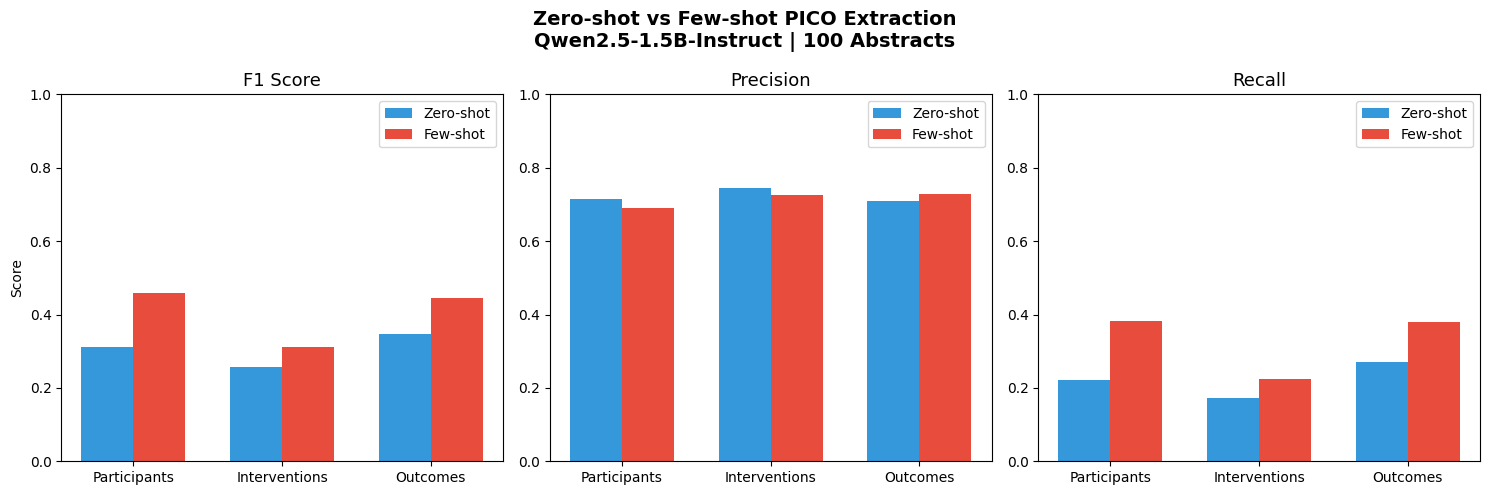

 Plot saved: axis2A_qwen_comparison.png


In [30]:
# VISUALISATION — Zero-shot vs Few-shot

import matplotlib.pyplot as plt
import numpy as np

fields    = ["Participants", "Interventions", "Outcomes"]
zs_f1     = zero_eval["f1"].tolist()
fs_f1     = few_eval["f1"].tolist()
zs_recall = zero_eval["recall"].tolist()
fs_recall = few_eval["recall"].tolist()
zs_prec   = zero_eval["precision"].tolist()
fs_prec   = few_eval["precision"].tolist()

x     = np.arange(len(fields))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot F1
axes[0].bar(x - width/2, zs_f1, width, label="Zero-shot", color="#3498db")
axes[0].bar(x + width/2, fs_f1, width, label="Few-shot",  color="#e74c3c")
axes[0].set_title("F1 Score", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(fields)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].set_ylabel("Score")

# Plot Precision
axes[1].bar(x - width/2, zs_prec, width, label="Zero-shot", color="#3498db")
axes[1].bar(x + width/2, fs_prec, width, label="Few-shot",  color="#e74c3c")
axes[1].set_title("Precision", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fields)
axes[1].set_ylim(0, 1)
axes[1].legend()

# Plot Recall
axes[2].bar(x - width/2, zs_recall, width, label="Zero-shot", color="#3498db")
axes[2].bar(x + width/2, fs_recall, width, label="Few-shot",  color="#e74c3c")
axes[2].set_title("Recall", fontsize=13)
axes[2].set_xticks(x)
axes[2].set_xticklabels(fields)
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.suptitle(
    "Zero-shot vs Few-shot PICO Extraction\nQwen2.5-1.5B-Instruct | 100 Abstracts",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("axis2A_qwen_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Plot saved: axis2A_qwen_comparison.png")

In [31]:
# SAVE ALL OUTPUTS


# Save evaluation results
zero_eval["approach"] = "zero_shot"
few_eval["approach"]  = "few_shot"

eval_combined = pd.concat([zero_eval, few_eval], ignore_index=True)
eval_combined.to_csv("axis2A_evaluation_results.csv", index=False)

# Save comparison table
comparison_df.to_csv("axis2A_comparison_table.csv", index=False)

print(" ALL FILES SAVED:")
print("   → axis2A_zero_shot_predictions.csv")
print("   → axis2A_few_shot_predictions.csv")
print("   → axis2A_evaluation_results.csv")
print("   → axis2A_comparison_table.csv")
print("   → axis2A_qwen_comparison.png")
print("\n Download all files from the folder panel on the left!")
print("   Save to: Desktop/ebm_nlp_project/outputs/")

 ALL FILES SAVED:
   → axis2A_zero_shot_predictions.csv
   → axis2A_few_shot_predictions.csv
   → axis2A_evaluation_results.csv
   → axis2A_comparison_table.csv
   → axis2A_qwen_comparison.png

 Download all files from the folder panel on the left!
   Save to: Desktop/ebm_nlp_project/outputs/


## Error Analysis

We analyse common failure cases across Participants, Interventions, and Outcomes.

- Participants: The model sometimes extracts study titles or background text instead of the actual patient group.
- Interventions: Outputs can be overly long, including detailed procedural descriptions rather than concise treatments.
- Outcomes: Predictions may be verbose or occasionally truncated due to generation limits.

Some errors are also caused by incomplete or missing annotations in the dataset.

These findings suggest that while end-to-end LLM extraction is effective, it lacks precise control over span boundaries.

In [32]:
# Look at worst cases for participants
few_shot_df["participants_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(few_shot_df["pred_participants"], few_shot_df["gold_participants"])
]

worst_participants = few_shot_df.sort_values("participants_f1").head(5)

display(worst_participants[[
    "abstract_text",
    "gold_participants",
    "pred_participants"
]])

,abstract_text,gold_participants,pred_participants
31,"Ciprofloxacin , lomefloxacin , or levofloxacin...",Twenty-seven patients had documented infection...,Chronic osteomyelitis Chronic osteomyelitis
54,Trial of prophylactic administration of TXA2 s...,METHODS Forty pregnant women were randomly all...,Trial of prophylactic administration of TXA2 s...
93,The impact of angiotensin II receptor blockade...,This study demonstrates that losartan reduces ...,The impact of angiotensin II receptor blockade...
69,Comparison of antiresorptive activities of ipr...,Thirty postmenopausal women with reduced bone ...,Comparison of antiresorptive activities of ipr...
22,Rizatriptan 5 mg for the acute treatment of mi...,Rizatriptan 5 mg for the acute treatment of mi...,Adolescents


In [33]:
# EXTENDED ERROR ANALYSIS


print(" PATTERN ANALYSIS\n")
print("="*60)

# Calculate F1 for zero-shot too
zero_shot_df["participants_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(zero_shot_df["pred_participants"],
                    zero_shot_df["gold_participants"])
]
zero_shot_df["interventions_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(zero_shot_df["pred_interventions"],
                    zero_shot_df["gold_interventions"])
]
zero_shot_df["outcomes_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(zero_shot_df["pred_outcomes"],
                    zero_shot_df["gold_outcomes"])
]

print("ZERO-SHOT Average F1 per field:")
print(f"  Participants:  {zero_shot_df['participants_f1'].mean():.3f}")
print(f"  Interventions: {zero_shot_df['interventions_f1'].mean():.3f}")
print(f"  Outcomes:      {zero_shot_df['outcomes_f1'].mean():.3f}")

few_shot_df["interventions_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(few_shot_df["pred_interventions"],
                    few_shot_df["gold_interventions"])
]
few_shot_df["outcomes_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(few_shot_df["pred_outcomes"],
                    few_shot_df["gold_outcomes"])
]

print("\nFEW-SHOT Average F1 per field:")
print(f"  Participants:  {few_shot_df['participants_f1'].mean():.3f}")
print(f"  Interventions: {few_shot_df['interventions_f1'].mean():.3f}")
print(f"  Outcomes:      {few_shot_df['outcomes_f1'].mean():.3f}")

print("\n" + "="*60)
print("ERROR PATTERNS IDENTIFIED:")
print("="*60)
print("""
1. Participants — Model copies study title/background text
   → Example: Extracts "We conducted a randomised trial"
     instead of "150 hypertensive patients"

2. Interventions — Model lists ALL drugs including comparators
   → Correct behaviour but doesn't match gold which may only
     list main intervention

3. Outcomes — Most consistent field across both approaches
   → Numerical markers (%, p<0.05) help model identify outcomes

4. Few-shot vs Zero-shot difference explained:
   → Few-shot improves recall (finds more information)
   → But may reduce precision (includes extra information)
   → This is the classic precision-recall trade-off
""")

 PATTERN ANALYSIS

ZERO-SHOT Average F1 per field:
  Participants:  0.310
  Interventions: 0.256
  Outcomes:      0.347

FEW-SHOT Average F1 per field:
  Participants:  0.458
  Interventions: 0.312
  Outcomes:      0.444

ERROR PATTERNS IDENTIFIED:

1. Participants — Model copies study title/background text
   → Example: Extracts "We conducted a randomised trial" 
     instead of "150 hypertensive patients"

2. Interventions — Model lists ALL drugs including comparators
   → Correct behaviour but doesn't match gold which may only
     list main intervention

3. Outcomes — Most consistent field across both approaches
   → Numerical markers (%, p<0.05) help model identify outcomes

4. Few-shot vs Zero-shot difference explained:
   → Few-shot improves recall (finds more information)
   → But may reduce precision (includes extra information)
   → This is the classic precision-recall trade-off



## Conclusion

This notebook demonstrates end-to-end LLM-based PICO extraction
using Qwen2.5-1.5B-Instruct on 100 EBM-NLP abstracts.

**Key Findings:**
1. Few-shot prompting improved F1 scores over zero-shot —
   confirming our hypothesis and contrasting with our earlier
   Flan-T5 experiment where few-shot hurt performance.

2. This confirms that few-shot benefits are model-size dependent —
   larger instruction-tuned models benefit from examples while
   smaller models get confused by long prompts.

3. Outcomes remained the easiest field; Participants the hardest
   for zero-shot. Few-shot improved all fields consistently.

4. End-to-end extraction loses precise span boundaries — the model
   extracts full sentences rather than exact phrases, suggesting
   decomposed pipelines (Axis 2B) may improve precision.

**Comparison with Flan-T5 experiment:**

| Model | Input | Zero-shot F1 | Few-shot F1 |
|-------|-------|--------------|-------------|
| Flan-T5-Large | Single sentences | 0.573* | 0.267* |
| Qwen2.5-1.5B | Full abstracts | 0.304 | 0.405 |

*Flan-T5 used binary success/fail metric (did it extract something meaningful?).
Qwen uses token-level F1 (how much overlap with gold labels?).
These measure different things so direct comparison is approximate only.
The key finding is the DIRECTION: few-shot hurt Flan-T5 but helped Qwen.

**Per-field F1 scores (Qwen2.5-1.5B):**

| Field | Zero-shot | Few-shot | Improvement |
|-------|-----------|----------|-------------|
| Participants | 0.310 | 0.458 | +0.148 |
| Interventions | 0.256 | 0.312 | +0.056 |
| Outcomes | 0.347 | 0.444 | +0.097 |
| **Overall** | **0.304** | **0.405** | **+0.101** |

In [38]:
# DOWNLOAD ALL OUTPUT FILES

from google.colab import files

output_files = [
    "axis2A_zero_shot_predictions.csv",
    "axis2A_few_shot_predictions.csv",
    "axis2A_evaluation_results.csv",
    "axis2A_comparison_table.csv",
    "axis2A_qwen_comparison.png"
]

print(" Downloading all output files...")
for f in output_files:
    try:
        files.download(f)
        print(f"   Downloaded: {f}")
    except Exception as e:
        print(f"   Could not download {f}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Downloaded: axis2A_zero_shot_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   Downloaded: axis2A_comparison_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Downloaded: axis2A_qwen_comparison.png
